In [1]:
"""04_s2_cvae.ipynb

# 04_s2 — Revised CVAE (Stream 2)

**What this notebook does**: trains the SAME CVAE architecture as 04a on
stream-2 data with a lean, econometrically-derived conditioning vector.
No architectural changes. The point is to produce a CVAE baseline for
comparison against SigCWGAN and neural SDE.

**Key change**: conditioning is ~11 dims (7 econometric scalars + 4 regime
one-hot), NOT the 38-dim vector from stream 1 (which included 30 PCA-
compressed lagged log-signature dims that I think caused posterior collapse).

**Input**: `data/logsigs_s2.parquet`, `data/norm_stats_s2.json`

**Outputs**:
- `data/cvae_s2_model.pt` — trained CVAE weights
- `data/cvae_generated_logsigs_s2.parquet` — generated log-signatures
- `data/cvae_s2_params.json` — all parameters for downstream use
"""

%pip install -q torch polars pyarrow matplotlib numpy scikit-learn

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
print(f"Data directory: {DATA_DIR}")

import json
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}, device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

plt.rcParams.update({
    "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

# ════════════════════════════════════════════════════════════════════════════════
# CELL 1 — Load data
# ════════════════════════════════════════════════════════════════════════════════

df = pl.read_parquet(DATA_DIR / "logsigs_s2.parquet").sort("start_time")
with open(DATA_DIR / "norm_stats_s2.json") as f:
    norm_stats = json.load(f)

logsig_dim_orig = norm_stats["logsig_dim"]
print(f"Loaded {df.shape[0]:,} segments, log-sig dim = {logsig_dim_orig}")
print(f"Regime distribution:")
print(df["regime"].value_counts())


Mounted at /content/drive
Data directory: /content/drive/MyDrive/energy_synthetic_data/data
PyTorch 2.10.0+cu128, device: cuda
GPU: NVIDIA A100-SXM4-40GB
Loaded 6,530 segments, log-sig dim = 90
Regime distribution:
shape: (4, 2)
┌──────────┬───────┐
│ regime   ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ negative ┆ 800   │
│ spike    ┆ 1940  │
│ volatile ┆ 1827  │
│ calm     ┆ 1963  │
└──────────┴───────┘


In [2]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 2 — Prepare log-signatures (X) and conditioning vector (C)
# ════════════════════════════════════════════════════════════════════════════════

# --- X: log-signatures ---
ls_cols = [c for c in df.columns if c.startswith("ls_")]
X_raw   = df.select(ls_cols).to_numpy().astype(np.float32)

# Drop zero-variance columns
col_stds    = X_raw.std(axis=0)
active_cols = col_stds > 0.0
ls_cols_active = [c for c, keep in zip(ls_cols, active_cols) if keep]
X_raw = X_raw[:, active_cols]
logsig_dim = X_raw.shape[1]
print(f"Active log-sig dims: {logsig_dim} (dropped {(~active_cols).sum()} zero-variance)")

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_raw).astype(np.float32)

# --- C: conditioning vector (LEAN — no lagged PCA log-sigs) ---
# Econometric scalars from notebook 02
COND_SCALAR_COLS = []
for col in ['wind_prev_mean', 'nuclear_prev_mean', 'RV_prev',
            'wind_var_prev_mean', 'ccgt_fraction_prev_mean',
            'ocgt_active_prev_mean', 'har_rv_prev_mean']:
    if col in df.columns:
        COND_SCALAR_COLS.append(col)
    else:
        print(f"  Warning: {col} not in logsigs_s2 — skipping")

print(f"Conditioning scalars: {COND_SCALAR_COLS}")

scalar_feats = df.select(COND_SCALAR_COLS).to_pandas().astype(float).fillna(0).values.astype(np.float32)

scaler_C = StandardScaler()
scalar_scaled = scaler_C.fit_transform(scalar_feats).astype(np.float32)

# Regime one-hot (4 states)
REGIME_MAP = {"calm": 0, "volatile": 1, "spike": 2, "negative": 3}
N_REGIMES  = len(REGIME_MAP)
regime_labels = df["regime"].to_list()
regime_idx    = np.array([REGIME_MAP.get(r, 0) for r in regime_labels], dtype=np.int64)
regime_onehot = np.eye(N_REGIMES, dtype=np.float32)[regime_idx]

C_SCALAR_DIMS = scalar_scaled.shape[1]
C_REGIME_DIMS = N_REGIMES

# Full conditioning: [scalars | regime_onehot] — NO lagged PCA
C = np.concatenate([scalar_scaled, regime_onehot], axis=1).astype(np.float32)
cond_dim = C.shape[1]

print(f"\nConditioning vector: {cond_dim} dims")
print(f"  Scalars:    {C_SCALAR_DIMS} ({COND_SCALAR_COLS})")
print(f"  Regime OH:  {C_REGIME_DIMS}")
print(f"  NO lagged PCA (this is the key change vs stream 1)")
print(f"\nX shape: {X_scaled.shape}, C shape: {C.shape}")


Active log-sig dims: 89 (dropped 1 zero-variance)
Conditioning scalars: ['wind_prev_mean', 'nuclear_prev_mean', 'RV_prev', 'wind_var_prev_mean', 'ccgt_fraction_prev_mean', 'ocgt_active_prev_mean', 'har_rv_prev_mean']

Conditioning vector: 11 dims
  Scalars:    7 (['wind_prev_mean', 'nuclear_prev_mean', 'RV_prev', 'wind_var_prev_mean', 'ccgt_fraction_prev_mean', 'ocgt_active_prev_mean', 'har_rv_prev_mean'])
  Regime OH:  4
  NO lagged PCA (this is the key change vs stream 1)

X shape: (6530, 89), C shape: (6530, 11)


In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 3 — Train/val split (stratified)
# ════════════════════════════════════════════════════════════════════════════════

indices = np.arange(len(X_scaled))
train_idx, val_idx = train_test_split(
    indices, test_size=0.2, stratify=regime_labels, random_state=42
)

X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
C_train, C_val = C[train_idx], C[val_idx]

train_regimes = [regime_labels[i] for i in train_idx]
val_regimes   = [regime_labels[i] for i in val_idx]

print(f"Train: {len(train_idx):,}  Val: {len(val_idx):,}")
print(f"Train regimes: {Counter(train_regimes)}")
print(f"Val regimes:   {Counter(val_regimes)}")

# KDE augmentation for minority regimes
from sklearn.neighbors import KernelDensity

N_AUG = {"spike": 100, "negative": 200}
KDE_BW = 0.4
X_aug, C_aug = [], []
for regime_name, n_aug in N_AUG.items():
    idx_list = [i for i, r in enumerate(train_regimes) if r == regime_name]
    if not idx_list: continue
    kde = KernelDensity(bandwidth=KDE_BW, kernel="gaussian")
    kde.fit(X_train[idx_list])
    X_kde = kde.sample(n_aug, random_state=42).astype(np.float32)
    boot  = np.random.choice(len(idx_list), size=n_aug, replace=True)
    C_kde = C_train[[idx_list[b] for b in boot]]
    X_aug.append(X_kde); C_aug.append(C_kde)
    print(f"  {regime_name}: +{n_aug} KDE samples")

X_train_aug = np.concatenate([X_train] + X_aug) if X_aug else X_train
C_train_aug = np.concatenate([C_train] + C_aug) if C_aug else C_train
print(f"After augmentation: {len(X_train_aug):,} training samples")

# Tensors and DataLoader
BATCH_SIZE = 64
X_train_t = torch.tensor(X_train_aug).to(device)
C_train_t = torch.tensor(C_train_aug).to(device)
X_val_t   = torch.tensor(X_val).to(device)
C_val_t   = torch.tensor(C_val).to(device)
train_ds  = TensorDataset(X_train_t, C_train_t)
train_dl  = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
print(f"Batches/epoch: {len(train_dl)}")


Train: 5,224  Val: 1,306
Train regimes: Counter({'calm': 1570, 'spike': 1552, 'volatile': 1462, 'negative': 640})
Val regimes:   Counter({'calm': 393, 'spike': 388, 'volatile': 365, 'negative': 160})
  spike: +100 KDE samples
  negative: +200 KDE samples
After augmentation: 5,524 training samples
Batches/epoch: 86


In [4]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 4 — CVAE architecture (IDENTICAL to 04a as I wanted to do the CVAE with better inputs but I think it is a dead end)
# ════════════════════════════════════════════════════════════════════════════════

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.LayerNorm(dim), nn.LeakyReLU(0.2),
            nn.Dropout(dropout), nn.Linear(dim, dim), nn.LayerNorm(dim),
        )
        self.act = nn.LeakyReLU(0.2)
    def forward(self, x):
        return self.act(x + self.block(x))

class Encoder(nn.Module):
    def __init__(self, input_dim, cond_dim, hidden_dim, latent_dim, n_layers=1):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim + cond_dim, hidden_dim),
            nn.LayerNorm(hidden_dim), nn.LeakyReLU(0.2),
        )
        self.res_blocks = nn.Sequential(*[ResidualBlock(hidden_dim) for _ in range(n_layers)])
        self.mu      = nn.Linear(hidden_dim, latent_dim)
        self.log_var = nn.Linear(hidden_dim, latent_dim)
    def forward(self, x, c):
        h = self.input_proj(torch.cat([x, c], dim=1))
        h = self.res_blocks(h)
        return self.mu(h), self.log_var(h)

class Decoder(nn.Module):
    def __init__(self, latent_dim, cond_dim, hidden_dim, output_dim, n_layers=1):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, hidden_dim),
            nn.LayerNorm(hidden_dim), nn.LeakyReLU(0.2),
        )
        self.res_blocks = nn.Sequential(*[ResidualBlock(hidden_dim) for _ in range(n_layers)])
        self.output = nn.Linear(hidden_dim, output_dim)
    def forward(self, z, c):
        h = self.input_proj(torch.cat([z, c], dim=1))
        h = self.res_blocks(h)
        return self.output(h)

class CVAE(nn.Module):
    def __init__(self, input_dim, cond_dim, hidden_dim=512, latent_dim=64, n_layers=3):
        super().__init__()
        self.encoder = Encoder(input_dim, cond_dim, hidden_dim, latent_dim, n_layers)
        self.decoder = Decoder(latent_dim, cond_dim, hidden_dim, input_dim, n_layers)
        self.latent_dim = latent_dim
    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)
    def forward(self, x, c):
        mu, log_var = self.encoder(x, c)
        z = self.reparameterise(mu, log_var)
        return self.decoder(z, c), mu, log_var
    def generate(self, c, n_samples=1):
        with torch.no_grad():
            z = torch.randn(n_samples, self.latent_dim).to(c.device)
            return self.decoder(z, c)


In [5]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 5 — Hyperparameters and model instantiation
# ════════════════════════════════════════════════════════════════════════════════
# IDENTICAL to 04a's best Optuna result. Do NOT tune — we isolate the effect
# of better conditioning data, not better hyperparameters.

HIDDEN_DIM  = 100
LATENT_DIM  = 16
N_LAYERS    = 1
BETA_MAX    = 1.0
BETA_WARMUP = 50
min_kl      = 0.3
LR          = 3e-4
N_EPOCHS    = 1000
patience    = 300

model = CVAE(
    input_dim=logsig_dim, cond_dim=cond_dim,
    hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM, n_layers=N_LAYERS,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"CVAE: hidden={HIDDEN_DIM}, latent={LATENT_DIM}, layers={N_LAYERS}")
print(f"Trainable parameters: {n_params:,}")
print(f"Conditioning dim: {cond_dim} (stream 1 was ~38)")

def elbo_loss(x, x_hat, mu, log_var, beta=1.0):
    recon = F.mse_loss(x_hat, x, reduction="mean")
    kl_per_dim = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp())
    kl = torch.clamp(kl_per_dim, min=min_kl).mean()
    return recon + beta * kl, recon.item(), kl.item()

optimiser = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=N_EPOCHS, eta_min=LR/100)


CVAE: hidden=100, latent=16, layers=1
Trainable parameters: 66,721
Conditioning dim: 11 (stream 1 was ~38)


In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 6 — Training loop
# ════════════════════════════════════════════════════════════════════════════════

from sklearn.metrics.pairwise import rbf_kernel as sklearn_rbf

train_losses, val_losses, recon_losses, kl_losses = [], [], [], []
collapsed_dims_history = []
mmd_history = []

val_regime_masks = {
    r: torch.tensor([rv == r for rv in val_regimes], dtype=torch.bool).to(device)
    for r in REGIME_MAP
}
regime_recon_history = {r: [] for r in REGIME_MAP}

best_val_loss     = float("inf")
best_epoch        = 0
epochs_no_improve = 0
warmup_done       = False

for epoch in tqdm(range(N_EPOCHS), desc="Training CVAE (stream 2)"):
    beta = min(BETA_MAX, BETA_MAX * epoch / max(BETA_WARMUP, 1))

    if epoch == BETA_WARMUP and not warmup_done:
        epochs_no_improve = 0
        warmup_done = True

    # Train
    model.train()
    epoch_loss = epoch_recon = epoch_kl = 0.0
    for x_batch, c_batch in train_dl:
        optimiser.zero_grad()
        x_hat, mu, log_var = model(x_batch, c_batch)
        loss, recon, kl    = elbo_loss(x_batch, x_hat, mu, log_var, beta)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        epoch_loss += loss.item(); epoch_recon += recon; epoch_kl += kl

    n_batches    = len(train_dl)
    epoch_loss  /= n_batches
    epoch_recon /= n_batches
    epoch_kl    /= n_batches

    # Validate
    model.eval()
    with torch.no_grad():
        x_hat_val, mu_val, lv_val = model(X_val_t, C_val_t)
        val_loss, _, _ = elbo_loss(X_val_t, x_hat_val, mu_val, lv_val, beta)
        val_loss = val_loss.item()

        kl_per_dim  = -0.5 * (1 + lv_val - mu_val.pow(2) - lv_val.exp())
        pct_collapsed = (kl_per_dim.mean(0) < min_kl + 0.05).float().mean().item()
        collapsed_dims_history.append(pct_collapsed)

        for rname, mask in val_regime_masks.items():
            if mask.sum() > 0:
                regime_recon_history[rname].append(
                    F.mse_loss(x_hat_val[mask], X_val_t[mask]).item())
            else:
                regime_recon_history[rname].append(float("nan"))

        # Approx MMD every 50 epochs after warmup
        if epoch >= BETA_WARMUP and (epoch + 1) % 50 == 0:
            n_probe = min(300, len(C_val))
            probe_idx = np.random.choice(len(C_val), n_probe, replace=False)
            c_probe = torch.tensor(C_val[probe_idx]).to(device)
            z_probe = torch.randn(n_probe, LATENT_DIM).to(device)
            x_fake  = model.decoder(z_probe, c_probe).cpu().numpy()
            x_real  = X_val[probe_idx]
            gamma   = 1.0 / x_real.shape[1]
            K_rr = sklearn_rbf(x_real, x_real, gamma=gamma).mean()
            K_ff = sklearn_rbf(x_fake, x_fake, gamma=gamma).mean()
            K_rf = sklearn_rbf(x_real, x_fake, gamma=gamma).mean()
            mmd_history.append((epoch, float(K_rr + K_ff - 2 * K_rf)))

    scheduler.step()
    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    recon_losses.append(epoch_recon)
    kl_losses.append(epoch_kl)

    # Early stopping after warmup
    if epoch >= BETA_WARMUP:
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_no_improve = 0
            torch.save(model.state_dict(), DATA_DIR / "cvae_s2_model.pt")
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d} | train={epoch_loss:.4f} val={val_loss:.4f} "
              f"recon={epoch_recon:.4f} kl={epoch_kl:.4f} β={beta:.2f} "
              f"collapsed={pct_collapsed:.0%}")

print(f"\nBest: epoch {best_epoch+1}, val_loss={best_val_loss:.4f}")
model.load_state_dict(torch.load(DATA_DIR / "cvae_s2_model.pt"))


Training CVAE (stream 2):   5%|▌         | 50/1000 [00:23<07:03,  2.24it/s]

Epoch   50 | train=0.8563 val=0.8717 recon=0.4500 kl=0.4146 β=0.98 collapsed=56%


Training CVAE (stream 2):  10%|█         | 100/1000 [00:45<06:42,  2.23it/s]

Epoch  100 | train=0.8381 val=0.8555 recon=0.4313 kl=0.4069 β=1.00 collapsed=62%


Training CVAE (stream 2):  15%|█▌        | 150/1000 [01:08<06:20,  2.24it/s]

...

Training CVAE (stream 2):  95%|█████████▌| 950/1000 [07:01<00:22,  2.27it/s]

Epoch  950 | train=0.7737 val=0.8127 recon=0.3772 kl=0.3965 β=1.00 collapsed=50%


Training CVAE (stream 2): 100%|██████████| 1000/1000 [07:23<00:00,  2.25it/s]

Epoch 1000 | train=0.7786 val=0.8122 recon=0.3818 kl=0.3967 β=1.00 collapsed=50%

Best: epoch 894, val_loss=0.8004


<All keys matched successfully>

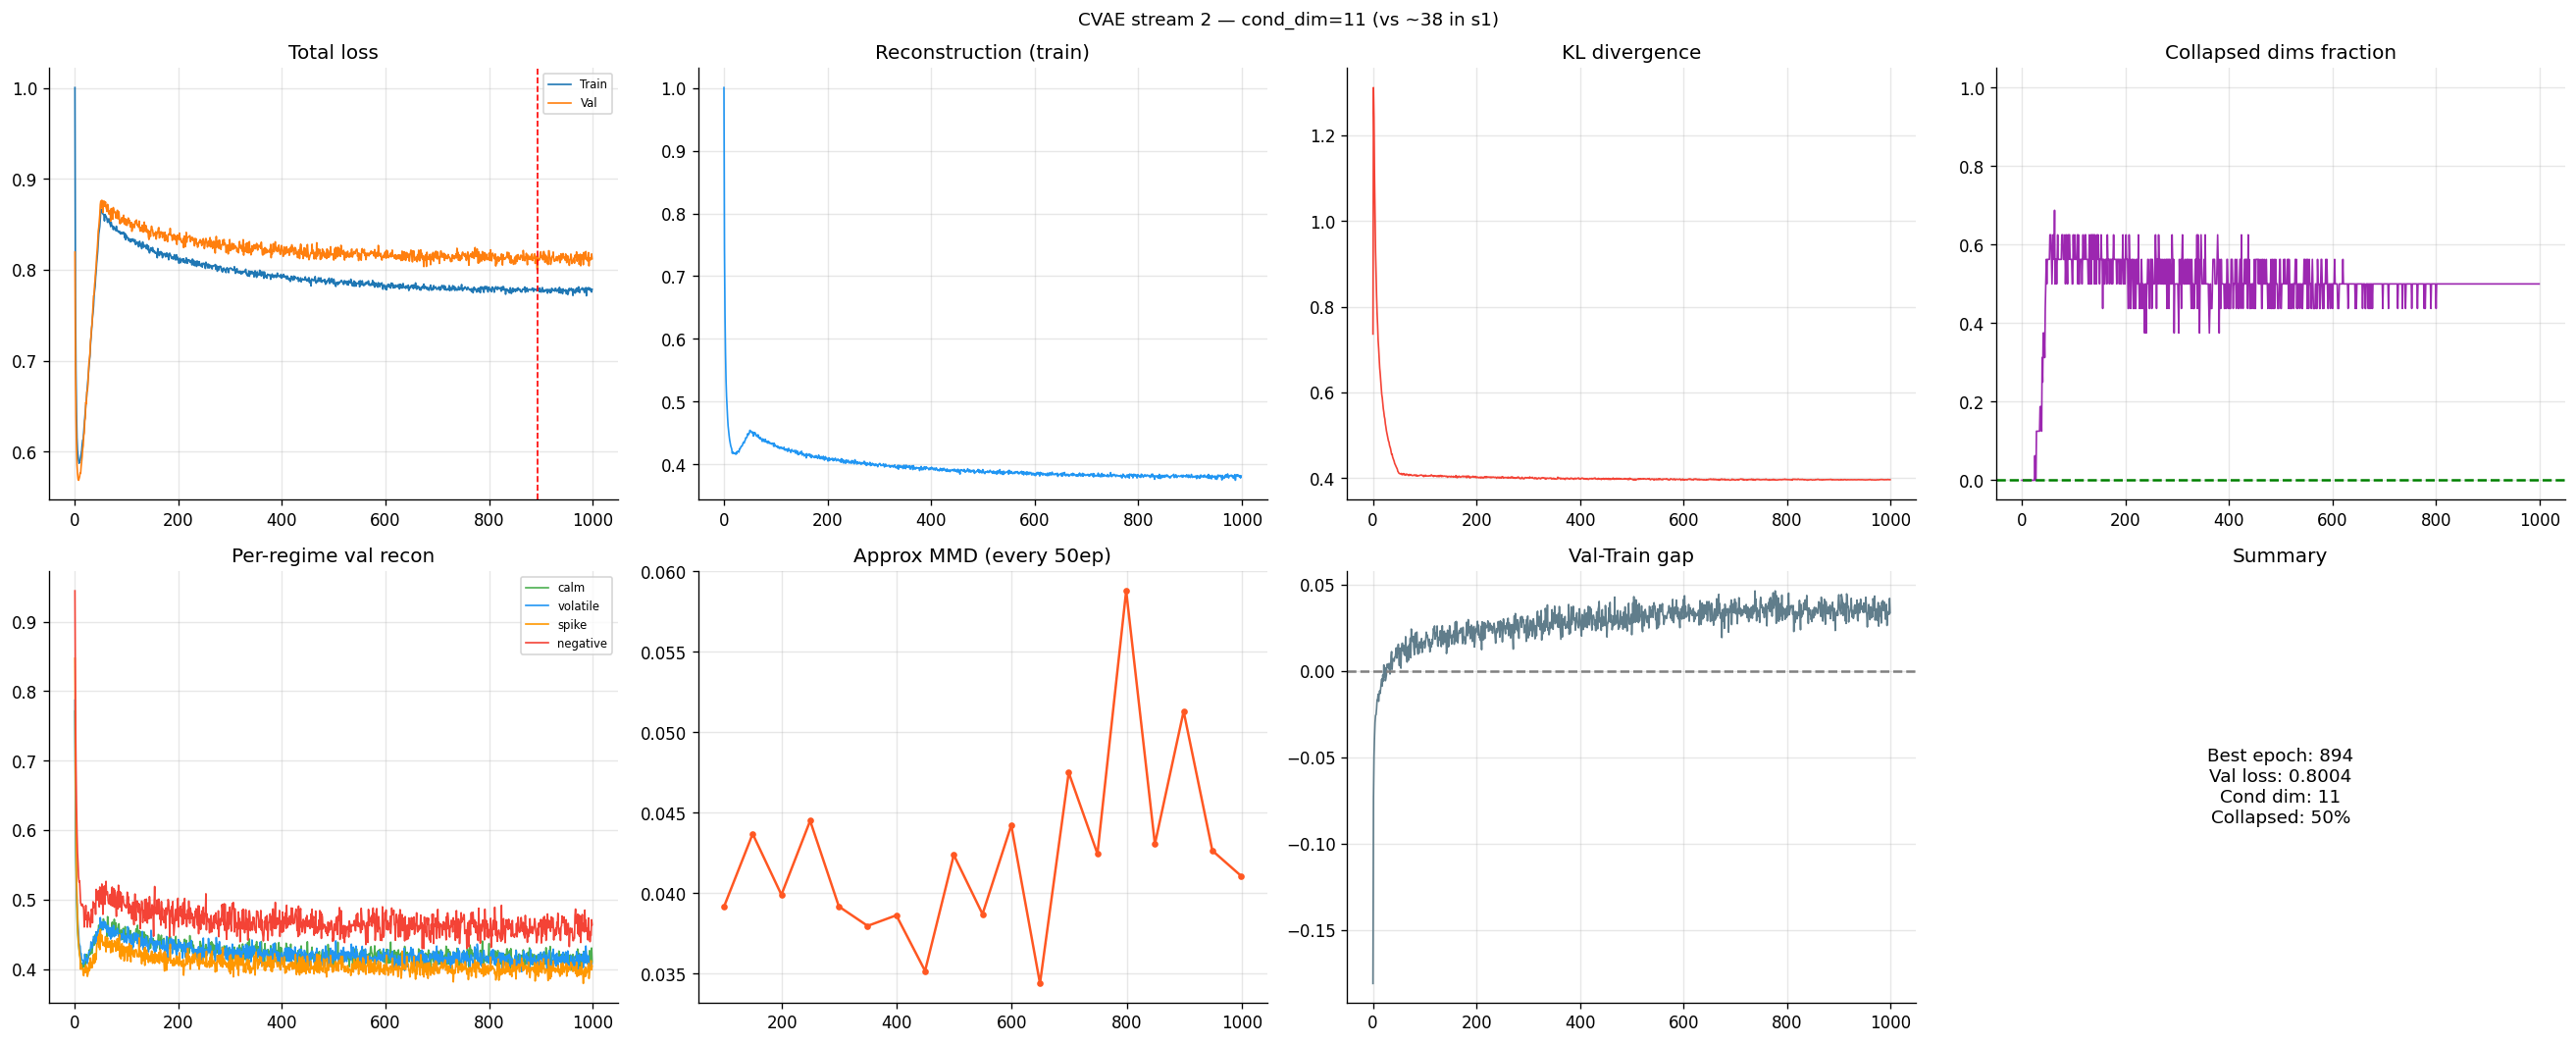

In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 7 — Training curves
# ════════════════════════════════════════════════════════════════════════════════

REGIME_COLORS = {"calm": "#4CAF50", "volatile": "#2196F3",
                 "spike": "#FF9800", "negative": "#F44336"}

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle(f"CVAE stream 2 — cond_dim={cond_dim} (vs ~38 in s1)", fontsize=11)

ax = axes[0,0]; ax.plot(train_losses, lw=1, label="Train"); ax.plot(val_losses, lw=1, label="Val")
ax.axvline(best_epoch, color="red", ls="--", lw=1); ax.set_title("Total loss"); ax.legend(fontsize=7)

ax = axes[0,1]; ax.plot(recon_losses, color="#2196F3", lw=1); ax.set_title("Reconstruction (train)")
ax = axes[0,2]; ax.plot(kl_losses, color="#F44336", lw=1); ax.set_title("KL divergence")
ax = axes[0,3]; ax.plot(collapsed_dims_history, color="#9C27B0", lw=1)
ax.axhline(0, color="green", ls="--"); ax.set_title("Collapsed dims fraction"); ax.set_ylim(-0.05, 1.05)

ax = axes[1,0]
for rn, rc in REGIME_COLORS.items():
    if regime_recon_history[rn]: ax.plot(regime_recon_history[rn], color=rc, lw=1, label=rn)
ax.set_title("Per-regime val recon"); ax.legend(fontsize=7)

ax = axes[1,1]
if mmd_history:
    me, mv = zip(*mmd_history); ax.plot(me, mv, 'o-', color="#FF5722", lw=1.5, ms=3)
ax.set_title("Approx MMD (every 50ep)")

ax = axes[1,2]; gap = [v-t for t,v in zip(train_losses, val_losses)]
ax.plot(gap, color="#607D8B", lw=1); ax.axhline(0, color="grey", ls="--"); ax.set_title("Val-Train gap")

ax = axes[1,3]; ax.text(0.5, 0.5, f"Best epoch: {best_epoch+1}\nVal loss: {best_val_loss:.4f}\n"
    f"Cond dim: {cond_dim}\nCollapsed: {collapsed_dims_history[best_epoch]:.0%}",
    ha="center", va="center", transform=ax.transAxes, fontsize=11)
ax.set_title("Summary"); ax.axis("off")

plt.tight_layout()
plt.savefig(DATA_DIR / "04_s2_training_curves.png", bbox_inches="tight", dpi=120)
plt.show()

Pool sizes: {'calm': 1963, 'volatile': 1827, 'spike': 1940, 'negative': 800}
Generated 10,000 log-signatures


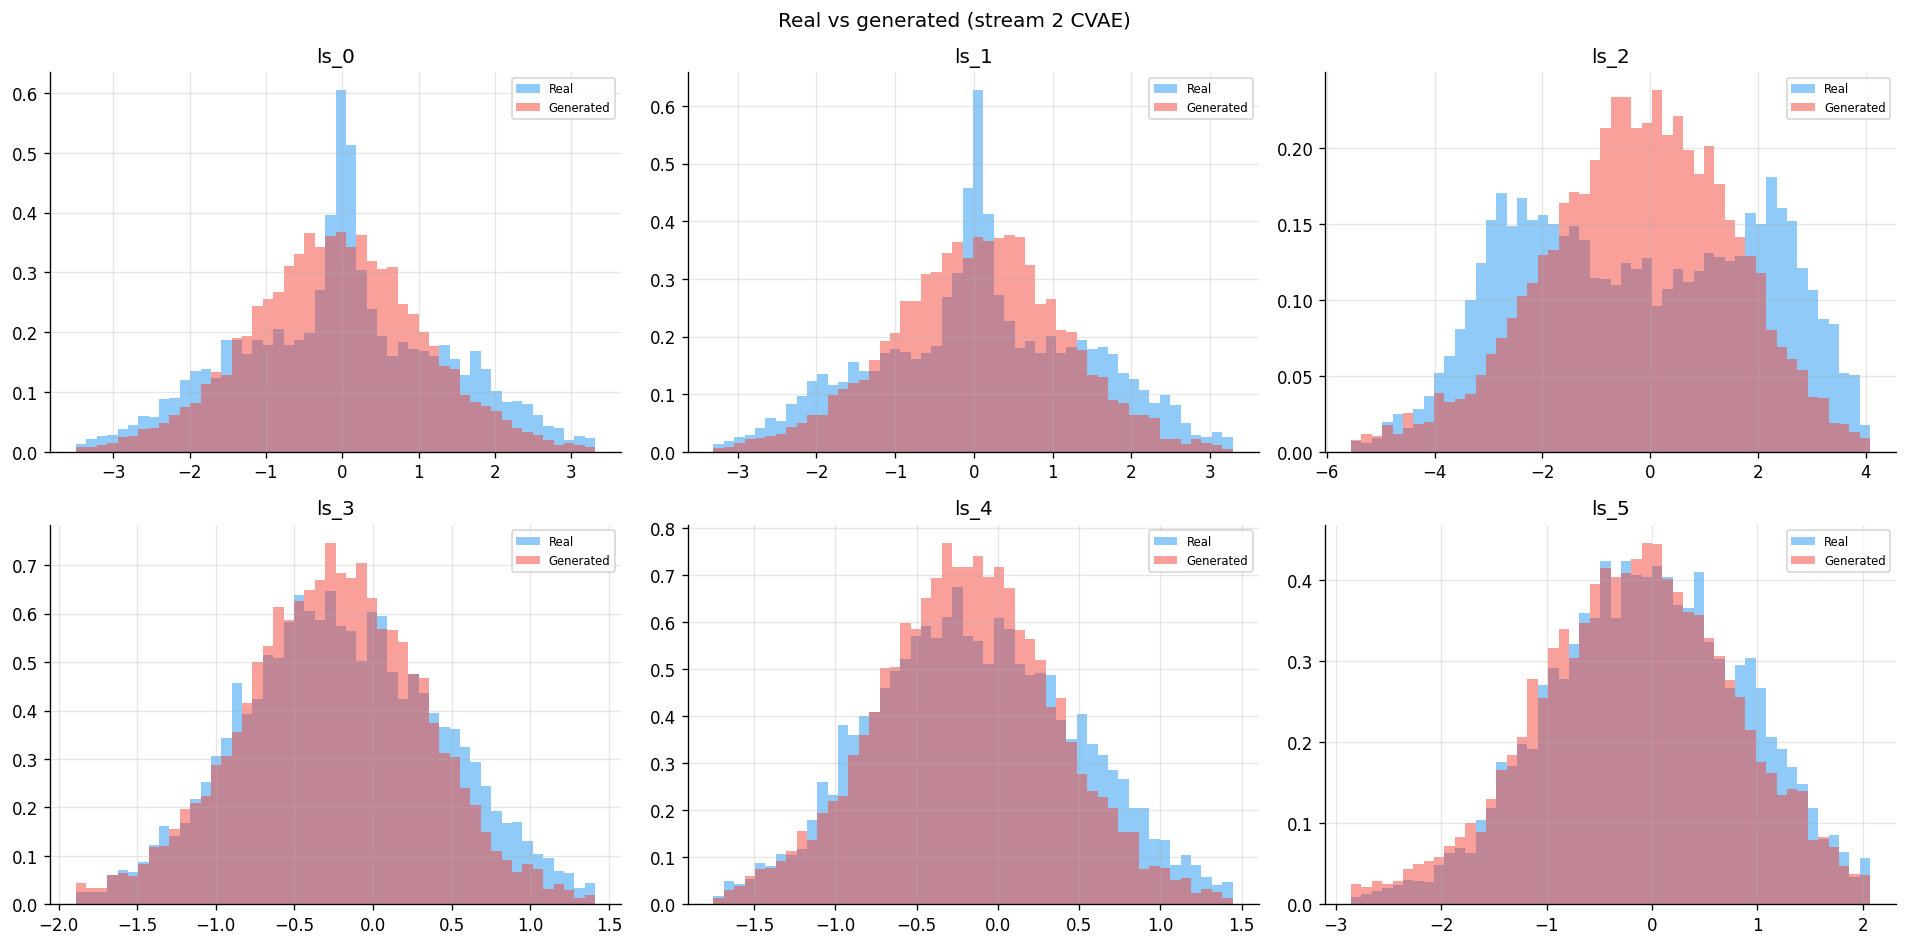

In [8]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 8 — Generation
# ════════════════════════════════════════════════════════════════════════════════

model.eval()
N_GENERATE = 10_000
np.random.seed(42)

TARGET_FRACTIONS = {"calm": 0.30, "volatile": 0.30, "spike": 0.25, "negative": 0.15}

# Build regime-stratified pool from full dataset
all_regimes = df["regime"].to_list()
regime_indices = {r: [i for i, rr in enumerate(all_regimes) if rr == r] for r in TARGET_FRACTIONS}
print("Pool sizes:", {r: len(v) for r, v in regime_indices.items()})

idx = []
for rname, frac in TARGET_FRACTIONS.items():
    n_r  = int(N_GENERATE * frac)
    pool = regime_indices[rname]
    idx.extend(np.random.choice(pool, size=n_r, replace=True).tolist())
idx = np.array(idx); np.random.shuffle(idx)

C_gen = torch.tensor(C[idx]).to(device)

# Temperature scaling by regime
T_GEN = {0: 1.3, 1: 1.3, 2: 1.8, 3: 1.8}
GEN_BATCH = 512
generated = []

with torch.no_grad():
    for i in range(0, N_GENERATE, GEN_BATCH):
        c_batch   = C_gen[i:i+GEN_BATCH]
        regime_oh = c_batch[:, C_SCALAR_DIMS:C_SCALAR_DIMS+C_REGIME_DIMS].cpu().numpy()
        regime_ids = regime_oh.argmax(axis=1)
        temps = torch.tensor([T_GEN[r] for r in regime_ids], dtype=torch.float32
                             ).to(device).unsqueeze(1)
        z     = torch.randn(len(c_batch), LATENT_DIM).to(device) * temps
        x_hat = model.decoder(z, c_batch)
        generated.append(x_hat.cpu().numpy())

generated = np.concatenate(generated)
generated_unnorm = scaler_X.inverse_transform(generated)
print(f"Generated {len(generated):,} log-signatures")

# Quick distribution check
real_logsigs = scaler_X.inverse_transform(X_scaled)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Real vs generated (stream 2 CVAE)")
for i, ax in enumerate(axes.flat):
    lo, hi = np.percentile(real_logsigs[:, i], [1, 99])
    ax.hist(real_logsigs[:, i], bins=50, density=True, alpha=0.5, color="#2196F3",
            label="Real", range=(lo, hi))
    ax.hist(generated_unnorm[:, i], bins=50, density=True, alpha=0.5, color="#F44336",
            label="Generated", range=(lo, hi))
    ax.set_title(f"ls_{i}"); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(DATA_DIR / "04_s2_distributions.png", bbox_inches="tight")
plt.show()


In [9]:

# ════════════════════════════════════════════════════════════════════════════════
# CELL 9 — Save outputs
# ════════════════════════════════════════════════════════════════════════════════

cond_regimes = [all_regimes[i] for i in idx]
gen_records = {"sample_id": list(range(N_GENERATE)), "regime": cond_regimes}
for j, col in enumerate(ls_cols_active):
    gen_records[col] = generated_unnorm[:, j].tolist()

df_gen = pl.DataFrame(gen_records)
out_path = DATA_DIR / "cvae_generated_logsigs_s2.parquet"
df_gen.write_parquet(out_path)
print(f"Saved: {out_path.name} ({out_path.stat().st_size/1e6:.2f} MB)")

params = {
    "regime_map":       REGIME_MAP,
    "c_scalar_dims":    C_SCALAR_DIMS,
    "c_regime_dims":    C_REGIME_DIMS,
    "cond_scalar_cols": COND_SCALAR_COLS,
    "t_gen":            T_GEN,
    "latent_dim":       LATENT_DIM,
    "hidden_dim":       HIDDEN_DIM,
    "n_layers":         N_LAYERS,
    "cond_dim":         cond_dim,
    "logsig_dim":       logsig_dim,
    "best_epoch":       best_epoch + 1,
    "best_val_loss":    best_val_loss,
    "collapse_at_best": collapsed_dims_history[best_epoch],
    "X_mean":           scaler_X.mean_.tolist(),
    "X_scale":          scaler_X.scale_.tolist(),
    "C_mean":           scaler_C.mean_.tolist(),
    "C_scale":          scaler_C.scale_.tolist(),
}
with open(DATA_DIR / "cvae_s2_params.json", "w") as f:
    json.dump(params, f, indent=2)
print("Saved: cvae_s2_params.json")

print(f"\nStream 2 CVAE files:")
for fp in sorted(DATA_DIR.glob("*s2*")):
    print(f"  {fp.name}: {fp.stat().st_size/1e3:.1f} KB")

Saved: cvae_generated_logsigs_s2.parquet (3.97 MB)
Saved: cvae_s2_params.json

Stream 2 CVAE files:
  03_s2_levy_area.png: 70.6 KB
  03_s2_signature_pca.png: 165.7 KB
  04_s2_distributions.png: 76.7 KB
  04_s2_training_curves.png: 266.7 KB
  cvae_generated_logsigs_s2.parquet: 3973.9 KB
  cvae_s2_model.pt: 278.3 KB
  cvae_s2_params.json: 5.4 KB
  feature_analysis_s2.json: 4.4 KB
  logsigs_s2.parquet: 5227.9 KB
  norm_stats_s2.json: 0.3 KB
  segments_s2.parquet: 1449.1 KB
